# 03 — SfM-only hyperparameter tuning and ablations

This notebook consumes a completed frozen feature cache. It must not re-extract backbone features and must not use RevisitOP labels.

It defaults to a 256-D descriptor. For the separate compactness ablation, set `FUSION_OUTPUT_DIM_OVERRIDE = 128` in the first code cell **before** starting a fresh run. The frozen cache is reused; the effective configuration and run fingerprint record the override.

In [1]:
# Run this first in every fresh Colab runtime.  It intentionally does not use PYTHONPATH.
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import importlib
import os
import shutil
import subprocess
import sys

# Override this only if you use a fork/private clone URL.
REPO_URL = os.environ.get('CBIR_REPO_URL', 'https://github.com/armin-faraji/LightweightCBIR.git')
REPO_REVISION = os.environ.get('CBIR_REPO_REVISION', 'main')
# Leave as None for the reference 256-D experiment. Set to 128 only for a
# separate compactness ablation in a fresh Notebook 03 run.
FUSION_OUTPUT_DIM_OVERRIDE = None
PROJECT_ROOT = Path('/content/lightweight-cbir')
if not PROJECT_ROOT.is_dir():
    if not REPO_URL:
        raise RuntimeError('Set CBIR_REPO_URL before first use, or clone the repository to /content/lightweight-cbir.')
    subprocess.run(['git', 'clone', REPO_URL, str(PROJECT_ROOT)], check=True)
    subprocess.run(['git', '-C', str(PROJECT_ROOT), 'checkout', REPO_REVISION], check=True)
os.chdir(PROJECT_ROOT)
required_project_files = (PROJECT_ROOT / 'pyproject.toml', PROJECT_ROOT / 'src' / 'cbir' / '__init__.py', PROJECT_ROOT / 'src' / 'cbir' / 'artifacts.py')
missing_project_files = [str(path.relative_to(PROJECT_ROOT)) for path in required_project_files if not path.is_file()]
if missing_project_files:
    raise RuntimeError('The cloned repository does not contain the Colab-ready project code: ' + ', '.join(missing_project_files) + '. Push the current repository, or set CBIR_REPO_URL/CBIR_REPO_REVISION to the matching commit.')
# Do not use an editable install here: its .pth file is not automatically
# re-read by an already-running Jupyter kernel.
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', '--no-deps', '--force-reinstall', '.'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'h5py', 'scipy', 'PyYAML', 'tqdm', 'matplotlib', 'Pillow'], check=True)

importlib.invalidate_caches()
try:
    import cbir
except ModuleNotFoundError as error:
    raise RuntimeError('The package installation completed but cbir is not visible to this kernel. Restart the runtime once, then rerun this first cell.') from error
print('cbir package:', cbir.__file__)

from cbir.artifacts import create_artifact_run, make_artifact_run_id
from cbir.cloud import mount_colab_drive, runtime_report, write_runtime_report
from cbir.config import config_to_dict, load_project_config
from cbir.utils import stable_hash

PERSISTENT_ROOT = mount_colab_drive() / 'lightweight-cbir'
PERSISTENT_ROOT.mkdir(parents=True, exist_ok=True)
CONFIG_PATH = Path('configs/colab.yaml')
cfg = load_project_config(CONFIG_PATH)
output_dim_override = FUSION_OUTPUT_DIM_OVERRIDE
if output_dim_override is None:
    output_dim_override = os.environ.get('CBIR_FUSION_OUTPUT_DIM')
if output_dim_override is not None:
    try:
        output_dim_override = int(output_dim_override)
    except (TypeError, ValueError) as error:
        raise ValueError('FUSION_OUTPUT_DIM_OVERRIDE must be a positive integer or None') from error
    if output_dim_override <= 0:
        raise ValueError('FUSION_OUTPUT_DIM_OVERRIDE must be a positive integer or None')
    cfg = replace(cfg, fusion=replace(cfg.fusion, output_dim=output_dim_override))
environment = runtime_report(project_root=PROJECT_ROOT)
config_fingerprint = stable_hash(config_to_dict(cfg))
RUN_ID = make_artifact_run_id(notebook='03', git_sha=environment['git_sha'], config_fingerprint=config_fingerprint)
ARTIFACT_RUN = create_artifact_run(PROJECT_ROOT / 'outputs', '03', run_id=RUN_ID, metadata={'git_sha': environment['git_sha'], 'config_fingerprint': config_fingerprint})
LOCAL_OUTPUT_DIR = ARTIFACT_RUN.local_dir
DRIVE_OUTPUT_ROOT = PERSISTENT_ROOT / 'notebook_outputs'
write_runtime_report(LOCAL_OUTPUT_DIR, project_root=PROJECT_ROOT, extra={'notebook': '03', 'config': str(CONFIG_PATH), 'effective_fusion_output_dim': cfg.fusion.output_dim})
shutil.copy2(CONFIG_PATH, ARTIFACT_RUN.path_for('config.yaml'))
ARTIFACT_RUN.write_json('effective_config.json', config_to_dict(cfg))
ARTIFACT_RUN.write_json('experiment_overrides.json', {'fusion_output_dim_override': output_dim_override, 'effective_fusion_output_dim': cfg.fusion.output_dim})
print('Project:', PROJECT_ROOT)
print('Artifacts:', LOCAL_OUTPUT_DIR)
print('Fusion descriptor dimension:', cfg.fusion.output_dim)

Mounted at /content/drive
Project: /content/lightweight-cbir
Artifacts: /content/lightweight-cbir/outputs/03/20260803T221154Z__nb-03__git-49f780c7cc39__cfg-61e88f9438b7
Fusion descriptor dimension: 256


## Restore metadata and the completed frozen feature cache

Training never reads the many cache shards directly from Drive. It stages the small SfM metadata files, restores the validated full cache to fast `/content`, and retains its local shards in RAM so random pair batches do not repeatedly deserialize them.

In [2]:
from cbir.cache import FeatureShardReader
from cbir.cloud import publish_file, stage_file
from cbir.data.sfm import Sfm30kMetadata
from cbir.workflow import restore_complete_sfm_cache

LOCAL_SFM_ROOT = cfg.sfm.metadata_path.parent
DRIVE_SFM_ROOT = PERSISTENT_ROOT / 'datasets' / 'sfm30k'
metadata_files = (cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
LOCAL_SFM_ROOT.mkdir(parents=True, exist_ok=True)
if not all(path is not None and path.is_file() for path in metadata_files):
    if all(path is not None and (DRIVE_SFM_ROOT / path.name).is_file() for path in metadata_files):
        for path in metadata_files:
            assert path is not None
            stage_file(DRIVE_SFM_ROOT / path.name, path)
    else:
        subprocess.run([sys.executable, 'scripts/prepare_sfm30k.py', '--config', str(CONFIG_PATH), '--image-source', 'none'], cwd=PROJECT_ROOT, check=True)
        for path in metadata_files:
            assert path is not None
            publish_file(path, DRIVE_SFM_ROOT / path.name)
if cfg.sfm.names_clusters_path is None:
    raise ValueError('configs/colab.yaml must define sfm.names_clusters_path')
metadata = Sfm30kMetadata.from_official_files(cfg.sfm.metadata_path, cfg.sfm.names_clusters_path)
cache_location = restore_complete_sfm_cache(cfg, metadata)
reader = FeatureShardReader(cache_location.local_dir)
# Pair batches touch many shards in a random order. The complete float16 cache is
# small enough for this Colab RAM tier, so retain every local shard after its first read.
reader.max_cached_shards = len(reader.manifest.shards)
# Preload once here, rather than repeatedly stalling random training batches on deserialization.
warmup_ids = tuple(shard.image_ids[0] for shard in reader.manifest.shards)
_ = reader.fetch(warmup_ids, layer_indices=reader.manifest.layer_indices, local_kind=cfg.fusion.local_kind)
del warmup_ids, _
if set(reader.image_ids) != set(metadata.image_ids()):
    raise RuntimeError('restored cache does not contain exactly the full SfM-30k protocol image IDs')
val_ids = metadata.image_ids('val')
val_cases = metadata.build_validation_cases()
ARTIFACT_RUN.write_json('cache_restore.json', {'cache_name': cache_location.cache_name, 'fingerprint': cache_location.fingerprint, 'local_dir': str(cache_location.local_dir), 'drive_dir': None if cache_location.drive_dir is None else str(cache_location.drive_dir)})
cache_size_gib = sum(shard.bytes for shard in reader.manifest.shards) / 2**30
print(f'Using restored cache: {cache_location.local_dir} ({len(reader.manifest.shards)} shards, {cache_size_gib:.2f} GiB retained in RAM)')

Using restored cache: /content/cbir_cache/sfm30k__dinov2-vits14-reg__c9263905d61e (115 shards, 0.74 GiB retained in RAM)


## Establish frozen CLS baseline

This is B0. Save its SfM R@1/R@5/R@10/MRR before trained heads are compared.

In [3]:
from cbir.evaluation import evaluate_sfm_verified_pairs, final_cls_descriptors_from_cache

baseline = final_cls_descriptors_from_cache(reader, val_ids)
baseline_report = evaluate_sfm_verified_pairs(baseline, val_ids, val_cases)
ARTIFACT_RUN.write_json('baseline_metrics.json', {
    'recall_at_1': baseline_report.recall_at_1,
    'recall_at_5': baseline_report.recall_at_5,
    'recall_at_10': baseline_report.recall_at_10,
    'mrr': baseline_report.mrr,
})
print(baseline_report)

SfmRetrievalReport(num_queries=1691, recall_at_1=0.9201655824955648, recall_at_5=0.9461856889414547, recall_at_10=0.9574216439976345, mrr=0.9336657129040622, ranks={'22826c9fc4f15fe329b6acb2e0802688': 1, '15b67c52c1d71895b9b1ca0cc1770989': 1, 'a6f1426fa88f3a9d78ebd80008562153': 1, '034509ca758765afb5d2acb8766c72ac': 1, '25cb5532e56e045a7af24b652469d897': 1, '29c62d3c6aa9f57972564d18214e9d47': 1, '074b69f95e6e8809623014c4a819bede': 1, '264913428fa7c8afc6f447af209e5083': 1, '28cb3c3a45889acbfda52c669552b71e': 1, '48f1a1dd1c7b318e9cb14f9abfb5bfeb': 1, '078092f6c77552f0221d70da6f5d193d': 1, '3090b4a85fa9663dec42b46ab7519a3a': 1, '24321968a41a70678f1bf7231b27664f': 1, '17f81d34f5e7fd9ac706454ac83069bd': 1, '11059d70410bd98d4ca9d433260e665f': 1, '4190afa1b84476541b99507b6391989e': 1, '273e096644f43e3e38aed6155663c47d': 1, 'd7212ca0cf8979670f2e2a8a457709c2': 1, '15911544854eb4de624927fc29e4c76c': 1, '9ca47f20b44b7bb65a11a098569f286f': 1, '02c736811970943854c2c89eff3b8578': 1, '905613a2597d225

## Causal gate ablation

Run uniform, static, and reliability modes with the same layer set/dimension/training budget. The cells below are intentionally independent, so a completed mode remains usable if a later mode fails or the runtime stops. Mean-vs-guided local pooling and last-only baselines are separate explicit configs, not hidden changes.

In [4]:
from dataclasses import replace

from cbir.cloud import publish_file
from cbir.config import config_to_dict, train_fingerprint
from cbir.fusion import ReliabilityGatedFusion
from cbir.plotting import SeriesData, plot_series
from cbir.training import HeadTrainer
from cbir.utils import seed_everything

# This is the complete, single source of truth for the layer/gate experiment
# matrix. Layer numbers are one-based because that is how they are discussed
# in the report; DINOv2 receives the converted zero-based indices internally.
EXPERIMENT_SPECS = (
    {'name': 'uniform_4_8_12', 'label': 'uniform (4, 8, 12)', 'gate_mode': 'uniform', 'layers_one_based': (4, 8, 12)},
    {'name': 'static_4_8_12', 'label': 'static (4, 8, 12)', 'gate_mode': 'static', 'layers_one_based': (4, 8, 12)},
    {'name': 'reliability_4_8_12', 'label': 'reliability (4, 8, 12)', 'gate_mode': 'reliability', 'layers_one_based': (4, 8, 12)},
    {'name': 'uniform_10_11_12', 'label': 'uniform (10, 11, 12)', 'gate_mode': 'uniform', 'layers_one_based': (10, 11, 12)},
    {'name': 'static_10_11_12', 'label': 'static (10, 11, 12)', 'gate_mode': 'static', 'layers_one_based': (10, 11, 12)},
    {'name': 'reliability_10_11_12', 'label': 'reliability (10, 11, 12)', 'gate_mode': 'reliability', 'layers_one_based': (10, 11, 12)},
    {'name': 'uniform_8_10_12', 'label': 'uniform (8, 10, 12)', 'gate_mode': 'uniform', 'layers_one_based': (8, 10, 12)},
    {'name': 'static_8_10_12', 'label': 'static (8, 10, 12)', 'gate_mode': 'static', 'layers_one_based': (8, 10, 12)},
    {'name': 'reliability_8_10_12', 'label': 'reliability (8, 10, 12)', 'gate_mode': 'reliability', 'layers_one_based': (8, 10, 12)},
    {'name': 'uniform_6_9_12', 'label': 'uniform (6, 9, 12)', 'gate_mode': 'uniform', 'layers_one_based': (6, 9, 12)},
    {'name': 'static_6_9_12', 'label': 'static (6, 9, 12)', 'gate_mode': 'static', 'layers_one_based': (6, 9, 12)},
    {'name': 'reliability_6_9_12', 'label': 'reliability (6, 9, 12)', 'gate_mode': 'reliability', 'layers_one_based': (6, 9, 12)},
)
EXPERIMENTS_BY_NAME = {spec['name']: spec for spec in EXPERIMENT_SPECS}
EXPERIMENT_NAMES = tuple(spec['name'] for spec in EXPERIMENT_SPECS)
SPACED_UNIFORM_REFERENCE = 'uniform_4_8_12'
if len(EXPERIMENTS_BY_NAME) != len(EXPERIMENT_SPECS):
    raise ValueError('Experiment names must be unique')
for spec in EXPERIMENT_SPECS:
    layers_one_based = tuple(int(layer) for layer in spec['layers_one_based'])
    if spec['gate_mode'] not in {'uniform', 'static', 'reliability'}:
        raise ValueError(f"Unsupported gate mode in {spec['name']}: {spec['gate_mode']}")
    if len(layers_one_based) != 3 or len(set(layers_one_based)) != 3:
        raise ValueError(f"{spec['name']} must contain three distinct layers")
    if min(layers_one_based) < 1 or max(layers_one_based) > cfg.backbone.num_blocks:
        raise ValueError(f"{spec['name']} has layers outside [1, {cfg.backbone.num_blocks}]")
PERSISTENT_CHECKPOINT_ROOT = PERSISTENT_ROOT / 'checkpoints' / '03' / ARTIFACT_RUN.run_id

# Preserve results when this setup cell is rerun in the same Colab runtime.
# The legacy aliases make the already completed experiments usable after the
# clearer naming scheme is introduced.
LEGACY_EXPERIMENT_NAME_MAP = {
    'uniform': 'uniform_4_8_12',
    'static': 'static_4_8_12',
    'reliability': 'reliability_4_8_12',
    'uniform_last3': 'uniform_10_11_12',
    'static_last3': 'static_10_11_12',
    'reliability_last3': 'reliability_10_11_12',
}
previous_histories = globals().get('histories', {})
previous_results = globals().get('ablation_results', {})
histories = {}
ablation_results = {}
for previous_name, history in previous_histories.items():
    experiment_name = LEGACY_EXPERIMENT_NAME_MAP.get(previous_name, previous_name)
    previous_result = previous_results.get(previous_name)
    if experiment_name not in EXPERIMENTS_BY_NAME or previous_result is None:
        continue
    spec = EXPERIMENTS_BY_NAME[experiment_name]
    layers_one_based = tuple(spec['layers_one_based'])
    migrated_result = dict(previous_result)
    migrated_result.update({
        'experiment_name': experiment_name,
        'experiment_label': spec['label'],
        'gate_mode': spec['gate_mode'],
        'layer_indices_one_based': list(layers_one_based),
        'layer_indices_zero_based': [layer - 1 for layer in layers_one_based],
    })
    histories[experiment_name] = history
    ablation_results[experiment_name] = migrated_result

def _history_payload(history):
    return {
        'epochs': history.epochs,
        'best_epoch': history.best_epoch,
        'best_metric': history.best_metric,
        'best_checkpoint': None if history.best_checkpoint is None else str(history.best_checkpoint),
    }

def _experiment_details(experiment_name):
    try:
        spec = EXPERIMENTS_BY_NAME[experiment_name]
    except KeyError as error:
        raise KeyError(f'Unknown experiment: {experiment_name}') from error
    layers_one_based = tuple(int(layer) for layer in spec['layers_one_based'])
    return spec, tuple(layer - 1 for layer in layers_one_based)

def run_fusion_experiment(experiment_name: str):
    spec, layer_indices_zero_based = _experiment_details(experiment_name)
    fusion_cfg = replace(
        cfg.fusion,
        gate_mode=spec['gate_mode'],
        layer_indices=layer_indices_zero_based,
    )
    run_fingerprint = train_fingerprint(
        cache_fingerprint=reader.manifest.fingerprint,
        fusion=fusion_cfg,
        training=cfg.training,
    )
    local_run_dir = LOCAL_OUTPUT_DIR / 'runs' / experiment_name / run_fingerprint[:12]
    persistent_checkpoint = PERSISTENT_CHECKPOINT_ROOT / experiment_name / run_fingerprint[:12] / 'best.pt'

    def checkpoint_to_drive(local_checkpoint):
        publish_file(local_checkpoint, persistent_checkpoint)

    # Every head starts from the same RNG state. Thus, differences can be
    # attributed to the declared gate/layer configuration rather than its seed.
    seed_everything(cfg.training.seed)
    trainer = HeadTrainer(
        head=ReliabilityGatedFusion.from_config(fusion_cfg),
        reader=reader,
        train_pairs=metadata.train_pairs,
        fusion_config=fusion_cfg,
        training_config=cfg.training,
        validation_cases=val_cases,
        validation_image_ids=val_ids,
        output_dir=local_run_dir,
        checkpoint_callback=checkpoint_to_drive,
    )
    history = trainer.fit()
    if history.best_checkpoint is None or not persistent_checkpoint.is_file():
        raise RuntimeError(f'{experiment_name} did not produce a durable best checkpoint')
    result = {
        'experiment_name': experiment_name,
        'experiment_label': spec['label'],
        'gate_mode': spec['gate_mode'],
        'layer_indices_one_based': list(spec['layers_one_based']),
        'layer_indices_zero_based': list(layer_indices_zero_based),
        'run_fingerprint': run_fingerprint,
        'cache_fingerprint': reader.manifest.fingerprint,
        'fusion_config': config_to_dict(fusion_cfg),
        'training_config': config_to_dict(cfg.training),
        'persistent_checkpoint': str(persistent_checkpoint),
        **_history_payload(history),
    }
    ARTIFACT_RUN.write_json(f'runs/{experiment_name}/{run_fingerprint[:12]}/run_summary.json', result)
    return history, result

def write_experiment_ablation_summary():
    ARTIFACT_RUN.write_json('experiment_ablation.json', {
        'baseline': {
            'recall_at_1': baseline_report.recall_at_1,
            'recall_at_5': baseline_report.recall_at_5,
            'recall_at_10': baseline_report.recall_at_10,
            'mrr': baseline_report.mrr,
        },
        'experiment_specs': list(EXPERIMENT_SPECS),
        'runs': ablation_results,
    })

def record_fusion_experiment(experiment_name: str):
    history, result = run_fusion_experiment(experiment_name)
    histories[experiment_name] = history
    ablation_results[experiment_name] = result
    write_experiment_ablation_summary()
    print(f"{result['experiment_label']}: best SfM validation R@1={result['best_metric']:.4f} at epoch {result['best_epoch'] + 1}")
    return history, result

print(f'Run the {len(EXPERIMENT_NAMES)} named experiments below. Each is safe to resume independently.')

Run the 12 named experiments below. Each is safe to resume independently.


## Experiment group: layers (4, 8, 12)

The original spaced multi-level set. These layer numbers are one-based.

In [5]:
uniform_4_8_12_history, uniform_4_8_12_result = record_fusion_experiment('uniform_4_8_12')

uniform (4, 8, 12): best SfM validation R@1=0.9279 at epoch 22


### Static gate

Learns one shared set of layer weights for every image.

In [6]:
static_4_8_12_history, static_4_8_12_result = record_fusion_experiment('static_4_8_12')

static (4, 8, 12): best SfM validation R@1=0.9279 at epoch 22


### Reliability gate

Learns shared base weights and adjusts them per image using cached pooling entropy.

In [7]:
reliability_4_8_12_history, reliability_4_8_12_result = record_fusion_experiment('reliability_4_8_12')

reliability (4, 8, 12): best SfM validation R@1=0.9279 at epoch 22


## Experiment group: layers (10, 11, 12)

The final three blocks. Run all three gate variants; no new backbone extraction is required.

In [8]:
uniform_10_11_12_history, uniform_10_11_12_result = record_fusion_experiment('uniform_10_11_12')

uniform (10, 11, 12): best SfM validation R@1=0.9284 at epoch 12


In [9]:
static_10_11_12_history, static_10_11_12_result = record_fusion_experiment('static_10_11_12')

static (10, 11, 12): best SfM validation R@1=0.9284 at epoch 12


In [10]:
reliability_10_11_12_history, reliability_10_11_12_result = record_fusion_experiment('reliability_10_11_12')

reliability (10, 11, 12): best SfM validation R@1=0.9284 at epoch 12


## Experiment group: layers (8, 10, 12)

A late-biased, non-consecutive three-layer set. Run all three gate variants.

In [11]:
uniform_8_10_12_history, uniform_8_10_12_result = record_fusion_experiment('uniform_8_10_12')

uniform (8, 10, 12): best SfM validation R@1=0.9308 at epoch 21


In [12]:
static_8_10_12_history, static_8_10_12_result = record_fusion_experiment('static_8_10_12')

static (8, 10, 12): best SfM validation R@1=0.9308 at epoch 21


In [13]:
reliability_8_10_12_history, reliability_8_10_12_result = record_fusion_experiment('reliability_8_10_12')

reliability (8, 10, 12): best SfM validation R@1=0.9308 at epoch 21


## Experiment group: layers (6, 9, 12)

An evenly spaced middle-to-final three-layer set. Run all three gate variants.

In [14]:
uniform_6_9_12_history, uniform_6_9_12_result = record_fusion_experiment('uniform_6_9_12')

uniform (6, 9, 12): best SfM validation R@1=0.9273 at epoch 16


In [15]:
static_6_9_12_history, static_6_9_12_result = record_fusion_experiment('static_6_9_12')

static (6, 9, 12): best SfM validation R@1=0.9273 at epoch 16


In [16]:
reliability_6_9_12_history, reliability_6_9_12_result = record_fusion_experiment('reliability_6_9_12')

reliability (6, 9, 12): best SfM validation R@1=0.9273 at epoch 16


## Audit the executed experiments before interpretation

Run this after all 12 declared experiments. It compares the recorded histories exactly, reads the saved best checkpoints, and measures their learned gate weights on one fixed validation sample. It does not train or lock a model. The JSON report and large report-ready figures make it possible to distinguish a real tie from an inert gate or a layer-selection effect.

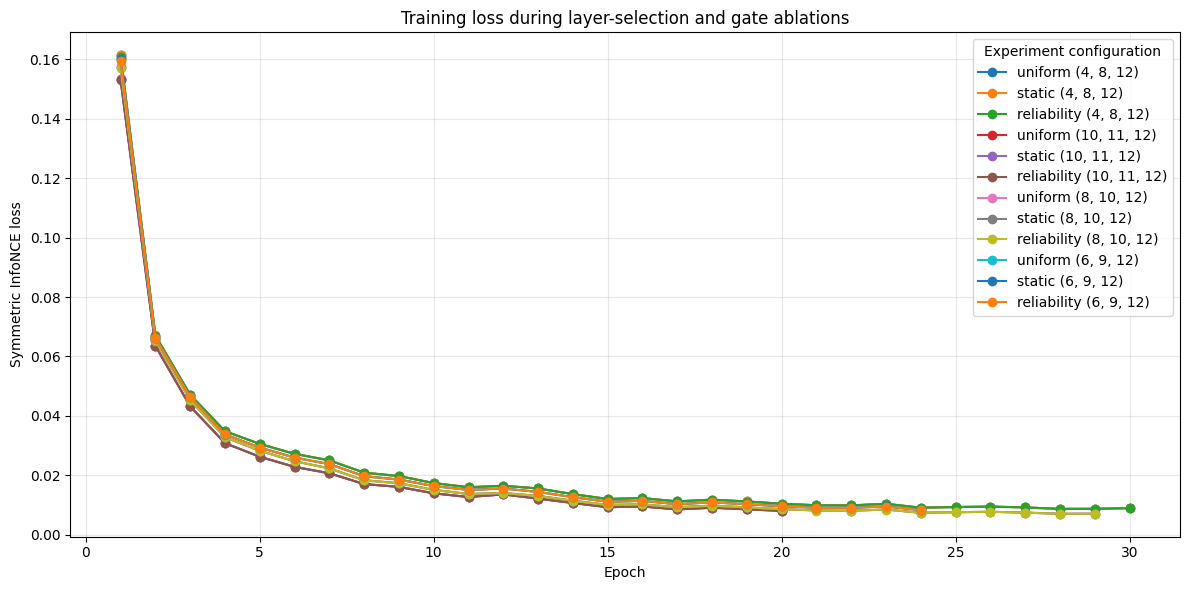

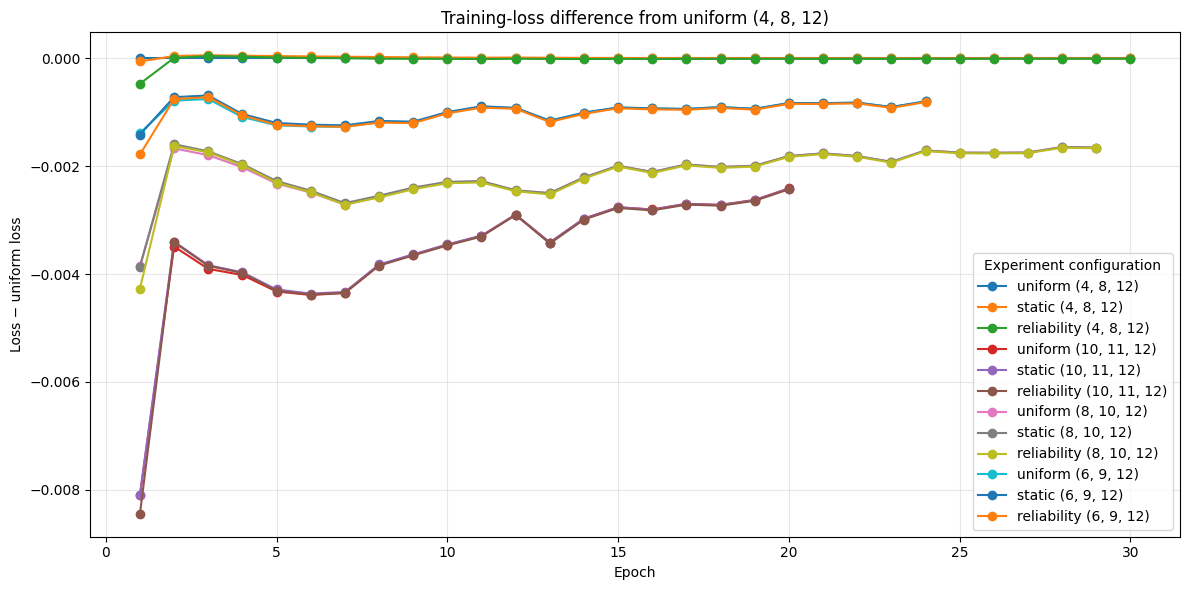

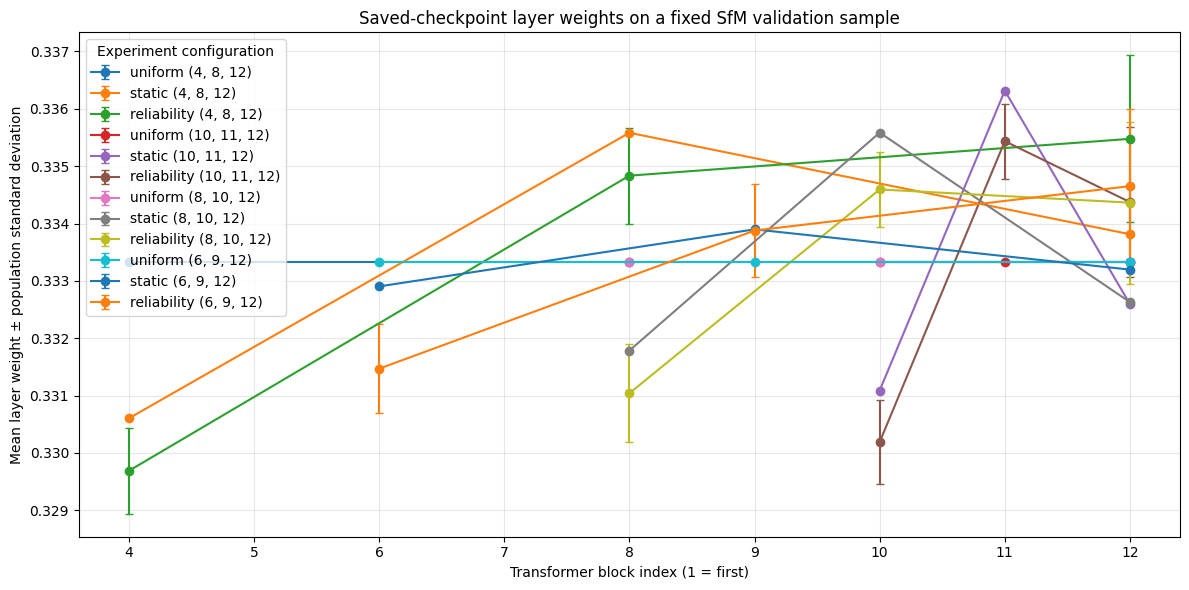

Wrote gate_integrity_diagnostics.json
uniform_4_8_12__vs__static_4_8_12: loss exact_equal=False, max |Δ|=5.857286133895134e-05, first differing epoch=1
uniform_4_8_12__vs__reliability_4_8_12: loss exact_equal=False, max |Δ|=0.00047118423211550686, first differing epoch=1
uniform_4_8_12__vs__uniform_10_11_12: loss exact_equal=False, max |Δ|=0.008101757976883811, first differing epoch=1
uniform_4_8_12__vs__static_10_11_12: loss exact_equal=False, max |Δ|=0.008086553152777148, first differing epoch=1
uniform_4_8_12__vs__reliability_10_11_12: loss exact_equal=False, max |Δ|=0.008443438988781193, first differing epoch=1
uniform_4_8_12__vs__uniform_8_10_12: loss exact_equal=False, max |Δ|=0.003854927717933221, first differing epoch=1
uniform_4_8_12__vs__static_8_10_12: loss exact_equal=False, max |Δ|=0.0038611329835670505, first differing epoch=1
uniform_4_8_12__vs__reliability_8_10_12: loss exact_equal=False, max |Δ|=0.004269419390006329, first differing epoch=1
uniform_4_8_12__vs__uniform_

In [17]:
from itertools import combinations

import numpy as np
import torch
import torch.nn.functional as functional
import matplotlib.pyplot as plt
from IPython.display import display

from cbir.cache import sha256_file
from cbir.config import FusionConfig

missing_experiments = [name for name in EXPERIMENT_NAMES if name not in ablation_results]
if missing_experiments:
    raise RuntimeError('Run every declared experiment before diagnostics: ' + ', '.join(missing_experiments))
if set(histories) != set(EXPERIMENT_NAMES) or set(ablation_results) != set(EXPERIMENT_NAMES):
    raise RuntimeError('histories and saved experiment results are inconsistent with EXPERIMENT_SPECS')

def compare_history_metric(left_history, right_history, metric):
    left_values = np.asarray([epoch[metric] for epoch in left_history.epochs], dtype=np.float64)
    right_values = np.asarray([epoch[metric] for epoch in right_history.epochs], dtype=np.float64)
    compared = min(len(left_values), len(right_values))
    absolute_difference = np.abs(left_values[:compared] - right_values[:compared])
    differing = np.flatnonzero(absolute_difference != 0)
    if differing.size:
        first_differing_epoch = int(left_history.epochs[int(differing[0])]['epoch']) + 1
    elif len(left_values) != len(right_values):
        first_differing_epoch = compared + 1
    else:
        first_differing_epoch = None
    return {
        'exact_equal': bool(len(left_values) == len(right_values) and np.array_equal(left_values, right_values)),
        'left_epoch_count': int(len(left_values)),
        'right_epoch_count': int(len(right_values)),
        'compared_epoch_count': int(compared),
        'max_abs_difference': float(absolute_difference.max()) if compared else None,
        'mean_abs_difference': float(absolute_difference.mean()) if compared else None,
        'first_differing_epoch': first_differing_epoch,
    }

def compare_state_dicts(left_state, right_state):
    left_keys = set(left_state)
    right_keys = set(right_state)
    common_keys = sorted(left_keys & right_keys)
    maximum = max(
        (float((left_state[key].detach().cpu() - right_state[key].detach().cpu()).abs().max()) for key in common_keys),
        default=0.0,
    )
    exact_equal = left_keys == right_keys and all(torch.equal(left_state[key], right_state[key]) for key in common_keys)
    return {
        'exact_equal': bool(exact_equal),
        'max_abs_difference': maximum,
        'left_only_keys': sorted(left_keys - right_keys),
        'right_only_keys': sorted(right_keys - left_keys),
        'common_tensor_count': len(common_keys),
    }

history_comparisons = {}
for left_mode, right_mode in combinations(EXPERIMENT_NAMES, 2):
    history_comparisons[f'{left_mode}__vs__{right_mode}'] = {
        metric: compare_history_metric(histories[left_mode], histories[right_mode], metric)
        for metric in ('loss', 'val_recall_at_1', 'lambda')
    }

checkpoint_payloads = {}
checkpoint_summaries = {}
for mode in EXPERIMENT_NAMES:
    spec = EXPERIMENTS_BY_NAME[mode]
    checkpoint_path = Path(ablation_results[mode]['persistent_checkpoint'])
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f'Missing durable {mode} checkpoint: {checkpoint_path}')
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    checkpoint_payloads[mode] = checkpoint
    saved_fusion_config = dict(checkpoint['fusion_config'])
    base_logits = checkpoint['model_state_dict']['base_logits'].detach().cpu()
    gate_raw = checkpoint['model_state_dict']['gate_raw'].detach().cpu()
    effective_lambda = functional.softplus(gate_raw) if saved_fusion_config['gate_mode'] == 'reliability' else torch.zeros_like(gate_raw)
    checkpoint_summaries[mode] = {
        'experiment_label': spec['label'],
        'layer_indices_one_based': list(spec['layers_one_based']),
        'path': str(checkpoint_path),
        'sha256': sha256_file(checkpoint_path),
        'saved_epoch': int(checkpoint['epoch']) + 1,
        'saved_gate_mode': saved_fusion_config['gate_mode'],
        'output_dim': int(saved_fusion_config['output_dim']),
        'trainable_parameter_count': int(sum(value.numel() for value in checkpoint['model_state_dict'].values())),
        'base_logits': [float(value) for value in base_logits.tolist()],
        'centered_base_logits': [float(value) for value in (base_logits - base_logits.mean()).tolist()],
        'gate_raw': float(gate_raw),
        'effective_lambda': float(effective_lambda),
    }

checkpoint_state_comparisons = {
    f'{left_mode}__vs__{right_mode}': compare_state_dicts(
        checkpoint_payloads[left_mode]['model_state_dict'],
        checkpoint_payloads[right_mode]['model_state_dict'],
    )
    for left_mode, right_mode in combinations(EXPERIMENT_NAMES, 2)
}

sample_image_ids = tuple(val_ids[: min(512, len(val_ids))])
if not sample_image_ids:
    raise RuntimeError('Validation sample is empty')
gate_weight_statistics = {}
sample_descriptors = {}
for mode in EXPERIMENT_NAMES:
    checkpoint = checkpoint_payloads[mode]
    raw_fusion_config = dict(checkpoint['fusion_config'])
    raw_fusion_config['layer_indices'] = tuple(raw_fusion_config['layer_indices'])
    saved_fusion_config = FusionConfig(**raw_fusion_config)
    head = ReliabilityGatedFusion.from_config(saved_fusion_config)
    head.load_state_dict(checkpoint['model_state_dict'])
    head = head.to(cfg.training.device).eval()
    sample_features = reader.fetch(
        sample_image_ids,
        layer_indices=saved_fusion_config.layer_indices,
        local_kind=saved_fusion_config.local_kind,
    )
    sample_features = {name: value.to(cfg.training.device) for name, value in sample_features.items()}
    with torch.inference_mode():
        descriptor, diagnostics = head(
            sample_features['cls'],
            sample_features['local'],
            sample_features['entropy'],
            return_diagnostics=True,
        )
    weights = diagnostics.layer_weights.detach().cpu()
    entropy = sample_features['entropy'].detach().cpu()
    gate_weight_statistics[mode] = {
        'sample_image_count': len(sample_image_ids),
        'per_layer': [
            {
                'layer_index_zero_based': int(layer_index),
                'layer_index_one_based': int(layer_index) + 1,
                'weight_mean': float(weights[:, position].mean()),
                'weight_std': float(weights[:, position].std(unbiased=False)),
                'weight_min': float(weights[:, position].min()),
                'weight_max': float(weights[:, position].max()),
                'entropy_mean': float(entropy[:, position].mean()),
                'entropy_std': float(entropy[:, position].std(unbiased=False)),
            }
            for position, layer_index in enumerate(saved_fusion_config.layer_indices)
        ],
    }
    sample_descriptors[mode] = descriptor.detach().cpu()
    del head, sample_features

descriptor_comparisons = {
    f'{left_mode}__vs__{right_mode}': {
        'mean_cosine_similarity': float(functional.cosine_similarity(sample_descriptors[left_mode], sample_descriptors[right_mode], dim=1).mean()),
        'max_abs_difference': float((sample_descriptors[left_mode] - sample_descriptors[right_mode]).abs().max()),
    }
    for left_mode, right_mode in combinations(EXPERIMENT_NAMES, 2)
}

loss_delta_series = {}
uniform_loss_by_epoch = {int(epoch['epoch']) + 1: epoch['loss'] for epoch in histories[SPACED_UNIFORM_REFERENCE].epochs}
for mode in EXPERIMENT_NAMES:
    loss_by_epoch = {int(epoch['epoch']) + 1: epoch['loss'] for epoch in histories[mode].epochs}
    common_epochs = sorted(set(uniform_loss_by_epoch) & set(loss_by_epoch))
    loss_delta_series[EXPERIMENTS_BY_NAME[mode]['label']] = SeriesData(
        x=common_epochs,
        y=[loss_by_epoch[epoch] - uniform_loss_by_epoch[epoch] for epoch in common_epochs],
    )

large_loss_series = {
    EXPERIMENTS_BY_NAME[mode]['label']: SeriesData(
        x=[int(epoch['epoch']) + 1 for epoch in histories[mode].epochs],
        y=[epoch['loss'] for epoch in histories[mode].epochs],
    )
    for mode in EXPERIMENT_NAMES
}
weight_summary_series = {
    EXPERIMENTS_BY_NAME[mode]['label']: SeriesData(
        x=[layer['layer_index_one_based'] for layer in statistics['per_layer']],
        y=[layer['weight_mean'] for layer in statistics['per_layer']],
        yerr=[layer['weight_std'] for layer in statistics['per_layer']],
    )
    for mode, statistics in gate_weight_statistics.items()
}
figure_large_loss, _ = plot_series(
    large_loss_series,
    title='Training loss during layer-selection and gate ablations',
    xlabel='Epoch',
    ylabel='Symmetric InfoNCE loss',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/experiment_ablation_loss_large.png'),
)
figure_loss_delta, _ = plot_series(
    loss_delta_series,
    title='Training-loss difference from uniform (4, 8, 12)',
    xlabel='Epoch',
    ylabel='Loss − uniform loss',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/experiment_ablation_loss_delta.png'),
)
figure_weights, _ = plot_series(
    weight_summary_series,
    title='Saved-checkpoint layer weights on a fixed SfM validation sample',
    xlabel='Transformer block index (1 = first)',
    ylabel='Mean layer weight ± population standard deviation',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/experiment_layer_weight_summary.png'),
)
for figure in (figure_large_loss, figure_loss_delta, figure_weights):
    display(figure)
    plt.close(figure)

gate_integrity_diagnostics = {
    'experiment_specs': list(EXPERIMENT_SPECS),
    'sample_image_ids': list(sample_image_ids),
    'history_comparisons': history_comparisons,
    'checkpoints': checkpoint_summaries,
    'checkpoint_state_comparisons': checkpoint_state_comparisons,
    'gate_weight_statistics': gate_weight_statistics,
    'descriptor_comparisons': descriptor_comparisons,
}
ARTIFACT_RUN.write_json('gate_integrity_diagnostics.json', gate_integrity_diagnostics)
write_experiment_ablation_summary()
print('Wrote gate_integrity_diagnostics.json')
for pair, comparison in history_comparisons.items():
    loss = comparison['loss']
    print(f"{pair}: loss exact_equal={loss['exact_equal']}, max |Δ|={loss['max_abs_difference']}, first differing epoch={loss['first_differing_epoch']}")

## Compare the completed layer-selection and gate ablations

{'uniform (4, 8, 12)': 0.9278533412182141, 'static (4, 8, 12)': 0.9278533412182141, 'reliability (4, 8, 12)': 0.9278533412182141, 'uniform (10, 11, 12)': 0.9284447072738025, 'static (10, 11, 12)': 0.9284447072738025, 'reliability (10, 11, 12)': 0.9284447072738025, 'uniform (8, 10, 12)': 0.9308101714961561, 'static (8, 10, 12)': 0.9308101714961561, 'reliability (8, 10, 12)': 0.9308101714961561, 'uniform (6, 9, 12)': 0.9272619751626257, 'static (6, 9, 12)': 0.9272619751626257, 'reliability (6, 9, 12)': 0.9272619751626257}


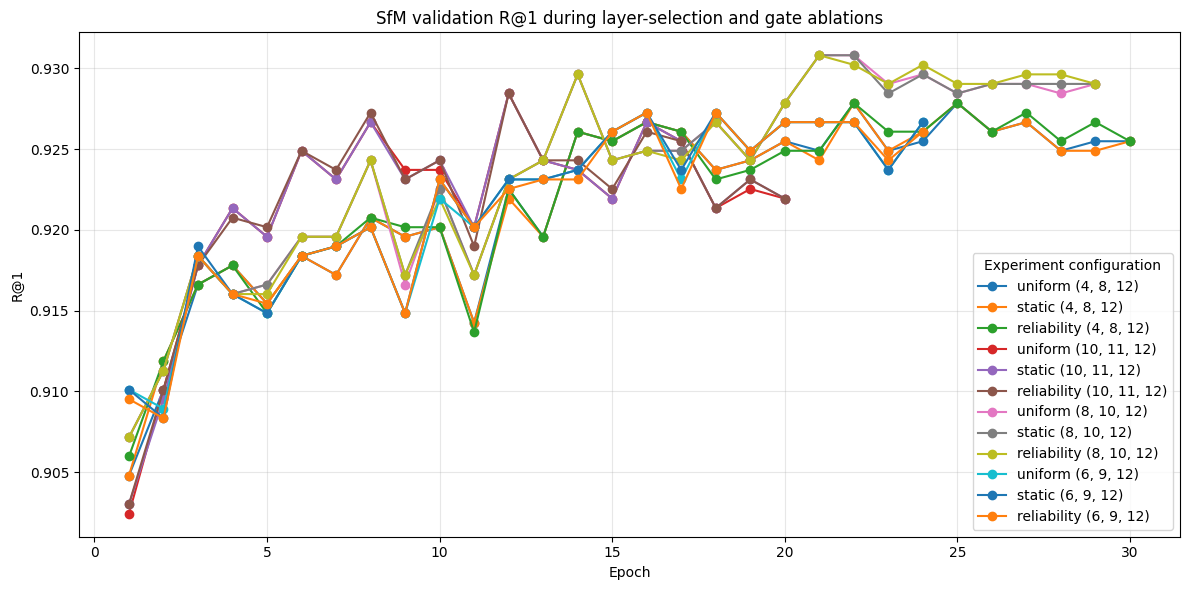

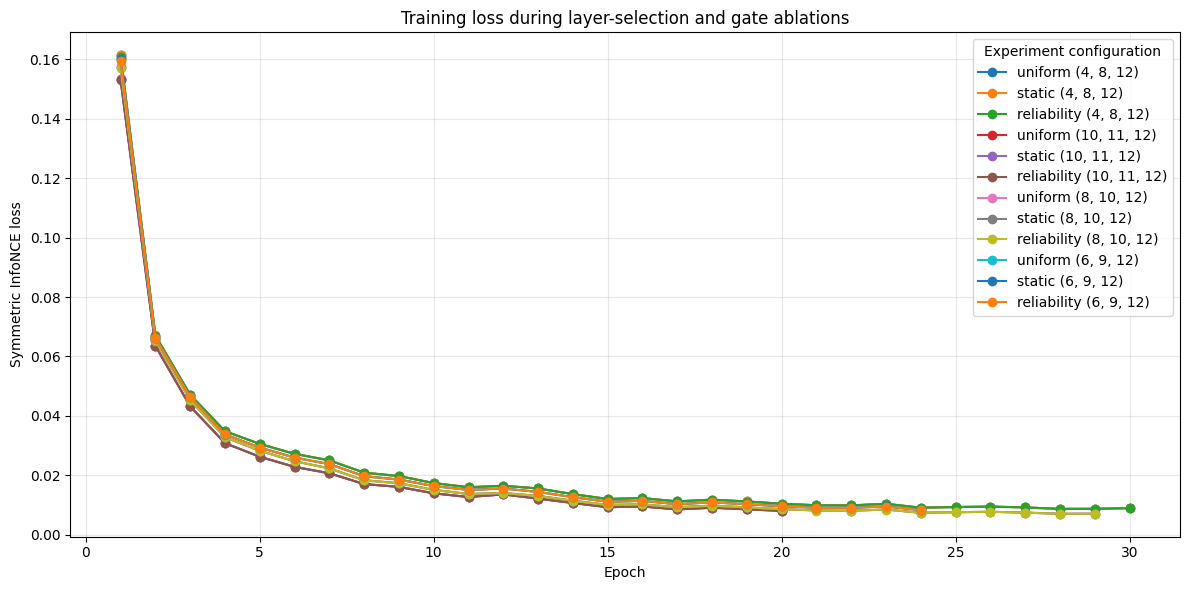

In [21]:
missing_experiments = [name for name in EXPERIMENT_NAMES if name not in ablation_results]
if missing_experiments:
    raise RuntimeError('Run every declared experiment before comparing or locking: ' + ', '.join(missing_experiments))

write_experiment_ablation_summary()
validation_series = {
    EXPERIMENTS_BY_NAME[mode]['label']: SeriesData(
        x=[epoch['epoch'] + 1 for epoch in histories[mode].epochs],
        y=[epoch['val_recall_at_1'] for epoch in histories[mode].epochs],
    )
    for mode in EXPERIMENT_NAMES
}
loss_series = {
    EXPERIMENTS_BY_NAME[mode]['label']: SeriesData(
        x=[epoch['epoch'] + 1 for epoch in histories[mode].epochs],
        y=[epoch['loss'] for epoch in histories[mode].epochs],
    )
    for mode in EXPERIMENT_NAMES
}
figure_r1, _ = plot_series(
    validation_series,
    title='SfM validation R@1 during layer-selection and gate ablations',
    xlabel='Epoch',
    ylabel='R@1',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/experiment_ablation_validation_r1.png'),
)
figure_loss, _ = plot_series(
    loss_series,
    title='Training loss during layer-selection and gate ablations',
    xlabel='Epoch',
    ylabel='Symmetric InfoNCE loss',
    legend_title='Experiment configuration',
    fig_size=(12, 6),
    save_path=ARTIFACT_RUN.path_for('figures/experiment_ablation_loss.png'),
)
print({EXPERIMENTS_BY_NAME[mode]['label']: ablation_results[mode]['best_metric'] for mode in EXPERIMENT_NAMES})

## Lock the SfM-selected checkpoint and publish outputs

Set `LOCKED_EXPERIMENT` only after comparing the SfM results above. This writes a durable lock that Notebook 04 reads; it must never be changed after looking at RevisitOP results. Then run the final publish cell exactly once after all desired plots/reports have been created.

In [19]:
from cbir.cache import sha256_file
from cbir.utils import atomic_write_json

# Change this to a completed experiment, for example 'reliability_8_10_12', after inspecting SfM only.
LOCKED_EXPERIMENT = None
if LOCKED_EXPERIMENT is not None:
    missing_experiments = [name for name in EXPERIMENT_NAMES if name not in ablation_results]
    if missing_experiments:
        raise RuntimeError('Run every declared experiment before locking: ' + ', '.join(missing_experiments))
    if LOCKED_EXPERIMENT not in ablation_results:
        raise KeyError(f'{LOCKED_EXPERIMENT!r} was not run in this notebook session')
    selected = ablation_results[LOCKED_EXPERIMENT]
    persistent_checkpoint = Path(selected['persistent_checkpoint'])
    if not persistent_checkpoint.is_file():
        raise FileNotFoundError(f'Durable checkpoint is missing: {persistent_checkpoint}')
    lock = {
        'selected_on': 'SfM-30k validation only',
        'notebook_run_id': ARTIFACT_RUN.run_id,
        'cache_fingerprint': reader.manifest.fingerprint,
        'selected_experiment': LOCKED_EXPERIMENT,
        'experiment_label': selected['experiment_label'],
        'gate_mode': selected['gate_mode'],
        'layer_indices_one_based': selected['layer_indices_one_based'],
        'run_fingerprint': selected['run_fingerprint'],
        'best_epoch': selected['best_epoch'],
        'best_metric': selected['best_metric'],
        'fusion_config': selected['fusion_config'],
        'training_config': selected['training_config'],
        'checkpoint_path': str(persistent_checkpoint),
        'checkpoint_sha256': sha256_file(persistent_checkpoint),
    }
    lock_path = PERSISTENT_ROOT / 'locked' / 'locked_run.json'
    atomic_write_json(lock_path, lock)
    ARTIFACT_RUN.write_json('locked_selection.json', lock)
    print('Locked SfM-selected checkpoint:', persistent_checkpoint)
else:
    print('No checkpoint locked yet. Set LOCKED_EXPERIMENT after choosing with SfM results only.')

No checkpoint locked yet. Set LOCKED_EXPERIMENT after choosing with SfM results only.


## Publish notebook outputs to Drive

Run this as the final cell after training and, if applicable, locking. Best checkpoints were already copied to Drive at every improvement; this publishes figures, summaries, and environment provenance.

In [20]:
published_output = ARTIFACT_RUN.publish(DRIVE_OUTPUT_ROOT)
print('Validated notebook artifacts published to:', published_output)

Validated notebook artifacts published to: /content/drive/MyDrive/lightweight-cbir/notebook_outputs/03/20260803T221154Z__nb-03__git-49f780c7cc39__cfg-61e88f9438b7
